<a href="https://colab.research.google.com/github/siddharth2004agrawal/AiProject1/blob/AiModules%2Fmodule-12/day12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ultralytics

In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
model = YOLO('yolov8n.pt')


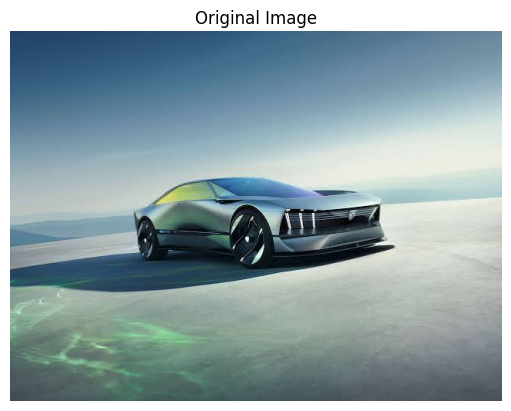

In [ ]:
image_url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRPS2Q2yHjKfD9ynhy43r-OPHjmub4HE60ayqNWRZkjEg&s=10'
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

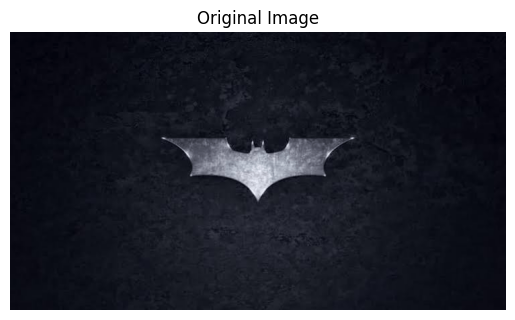

In [ ]:
image_url= '/content/bat.png'
# No need for requests.get() for local files
image = Image.open(image_url)
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()


0: 384x640 1 scissors, 242.8ms
Speed: 3.8ms preprocess, 242.8ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


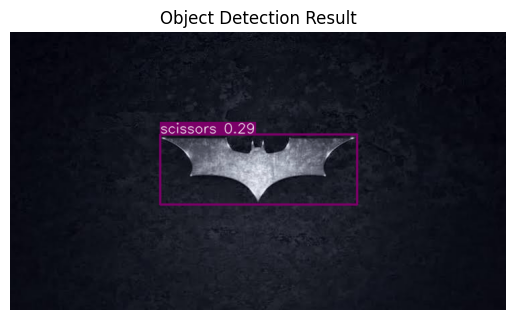

In [ ]:
results = model(image)
for r in results:
  im_array = r.plot()
  im = Image.fromarray(im_array[..., ::-1])
  plt.imshow(im)
  plt.title("Object Detection Result")
  plt.axis('off')
  plt.show()

HTTP Status Code: 200
Response Headers: {'Accept-Ranges': 'bytes', 'Access-Control-Allow-Origin': '*', 'Content-Security-Policy-Report-Only': "require-trusted-types-for 'script'; report-uri https://csp.withgoogle.com/csp/images-tbn", 'Cross-Origin-Resource-Policy': 'cross-origin', 'Cross-Origin-Opener-Policy-Report-Only': 'same-origin; report-to="images-tbn"', 'Report-To': '{"group":"images-tbn","max_age":2592000,"endpoints":[{"url":"https://csp.withgoogle.com/csp/report-to/images-tbn"}]}', 'Content-Length': '54515', 'X-Content-Type-Options': 'nosniff', 'Server': 'sffe', 'X-XSS-Protection': '0', 'Date': 'Tue, 07 Jul 2026 06:14:02 GMT', 'Expires': 'Wed, 07 Jul 2027 06:14:02 GMT', 'Cache-Control': 'public, max-age=31536000', 'Last-Modified': 'Wed, 24 Mar 2021 11:10:51 GMT', 'Content-Type': 'image/jpeg', 'Age': '2095'}


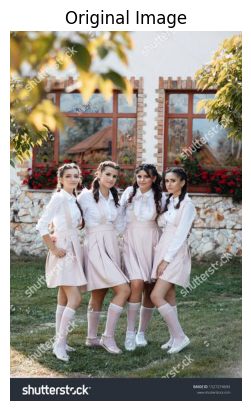

In [ ]:
image_url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQKLM5Wdpvx9HrFeV51FjzTv9rHW9hoLxvu4w7KbXG9_w&s=10'
response = requests.get(image_url)

print(f"HTTP Status Code: {response.status_code}")
print(f"Response Headers: {response.headers}")

content_type = response.headers.get('Content-Type', '')

if 'image' in content_type:
    try:
        image = Image.open(BytesIO(response.content))
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error opening image with PIL: {e}")
        print("Even though Content-Type indicates an image, PIL could not open it.")
        print("This might indicate corrupted or malformed image data.")
else:
    print(f"Error: The URL did not return image content. Content-Type: {content_type}")
    print("First 500 characters of response content:")
    print(response.content[:500].decode('utf-8', errors='ignore'))
    print("\nPlease try a different image URL.")


0: 640x416 4 persons, 251.6ms
Speed: 4.3ms preprocess, 251.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 416)


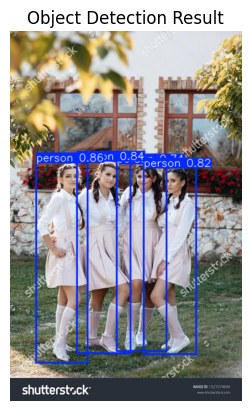

In [ ]:
results = model(image)
for r in results:
  im_array = r.plot()
  im = Image.fromarray(im_array[..., ::-1])
  plt.imshow(im)
  plt.title("Object Detection Result")
  plt.axis('off')
  plt.show()

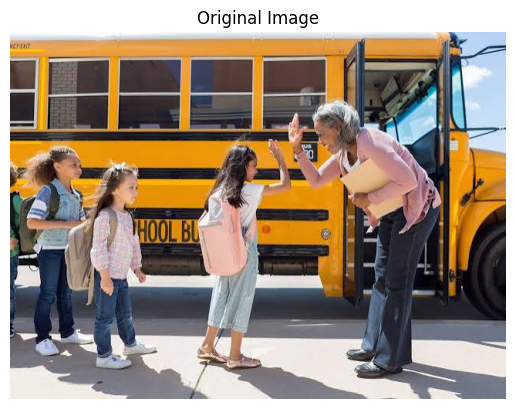

In [ ]:
image_url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSyYwXpmKvZwngfByL0Kl2YbRbwPX3GoUWHgNnrptRwug&s=10'
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()


0: 480x640 5 persons, 1 bus, 1 train, 1 truck, 1 handbag, 293.3ms
Speed: 6.1ms preprocess, 293.3ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


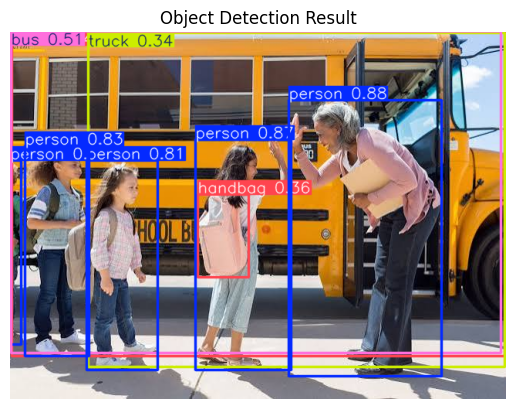

In [ ]:
results = model(image)
for r in results:
  im_array = r.plot()
  im = Image.fromarray(im_array[..., ::-1])
  plt.imshow(im)
  plt.title("Object Detection Result")
  plt.axis('off')
  plt.show()

In [ ]:
results[0].save('yolo_detection_results.jpg')
print("Detection results saved to'yolo_detection_results.jpg'in the current working directory.")

Detection results saved to'yolo_detection_results.jpg'in the current working directory.


In [ ]:
import cv2

In [ ]:
import numpy as np

In [ ]:
class_names=model.names

In [ ]:
import cv2
import numpy as np


In [ ]:
class_names=model.names

In [ ]:
person_class_id = None
for class_id, class_name in class_names.items():
  if class_name =='person':
    person_class_id = class_id
    break
    if person_class_id is not None:
      print(f" The classID for 'person' is: {person_class_id}")
    else:
      print(f"Class 'person' not found in the model's classes")

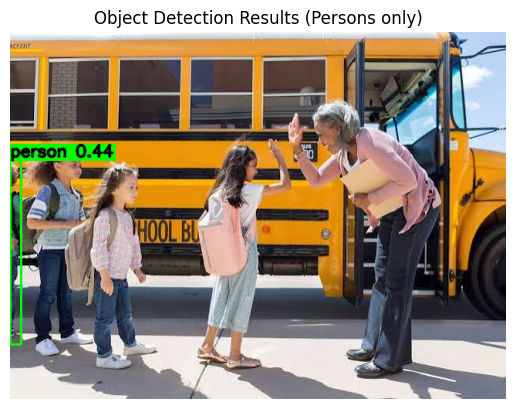

In [ ]:
if person_class_id is not None:
  image_np = np.array(image)
  img_br = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)
  detection = results[0]
  person_detection= detection.boxes[detection.boxes.cls==person_class_id]
  for box in person_detection:
    x1,y1,x2,y2=map(int,box.xyxy[0])
    conf=box.conf[0].item()
    cls=int(box.cls[0].item())

    class_name_for_box=class_names[cls]
  color=(0,255,0)
  thickness=2
  cv2.rectangle(img_br,(x1,y1),(x2,y2),color,thickness)

  label = f"{class_name_for_box} {conf:.2f}"
  font = cv2.FONT_HERSHEY_SIMPLEX
  font_scale = 0.7
  font_thickness = 2
  text_size, _ = cv2.getTextSize(label, font, font_scale, font_thickness)
  text_width, text_height = text_size

  cv2.rectangle(img_br, (x1, y1 - text_size[1]- 5), (x1 + text_size[0], y1), color, -1)
  cv2.putText(img_br, label, (x1, y1 - 5), font, font_scale, (0,0,0), font_thickness,cv2.LINE_AA)

  im_filtered_rgb=cv2.cvtColor(img_br,cv2.COLOR_BGR2RGB)
  im_filtered=Image.fromarray(im_filtered_rgb)
  plt.imshow(im_filtered)
  plt.title("Object Detection Results (Persons only)")
  plt.axis('off')
  plt.show()
else:
  print("Cannot filter by 'person' as its class ID was not found or an error occured")